<a href="https://colab.research.google.com/github/greeshmapj/AI-ML-nov2025-assignments/blob/main/Greeshma_CaseStudy_03_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Load Dataset**


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruit-and-vegetable-image-recognition' dataset.
Path to dataset files: /kaggle/input/fruit-and-vegetable-image-recognition


In [2]:
#Check folder structure
import os

os.listdir(path)

['validation', 'test', 'train']

In [3]:
os.listdir(path + "/train")

['capsicum',
 'sweetcorn',
 'orange',
 'tomato',
 'turnip',
 'ginger',
 'raddish',
 'pomegranate',
 'pineapple',
 'jalepeno',
 'apple',
 'carrot',
 'lettuce',
 'bell pepper',
 'eggplant',
 'beetroot',
 'kiwi',
 'pear',
 'cabbage',
 'cauliflower',
 'paprika',
 'lemon',
 'sweetpotato',
 'grapes',
 'cucumber',
 'corn',
 'banana',
 'garlic',
 'chilli pepper',
 'watermelon',
 'mango',
 'peas',
 'onion',
 'potato',
 'spinach',
 'soy beans']

## **2. Load Images Using ImageDataGenerator**

In [4]:
#ImageDataGenerator loads images in batches preventing memory crash
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32

#normalization
datagen = ImageDataGenerator(rescale=1/255)

train_data = datagen.flow_from_directory(
    path + "/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'         #one-hot encoding
)

val_data = datagen.flow_from_directory(
    path + "/validation",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.


# **3. Labeling Fruits & Vegetables**

In [5]:
fruit_classes = [
    'banana','apple','pear','grapes','orange','kiwi',
    'watermelon','pomegranate','pineapple','mango'
]

class_names = list(train_data.class_indices.keys())

def classify_type(class_name):
    if class_name.lower() in fruit_classes:
        return "Fruit"
    else:
        return "Vegetable"

# **4. Build CNN Model**

In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **5. Compile**

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# **6. Train**

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    batch_size=32
)

Epoch 1/10
 3/98 ━━━━━━━━━━━━━━━━━━━━ 2:15 1s/step - accuracy: 0.0243 - loss: 3.7041

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.1085 - loss: 3.1869 - val_accuracy: 0.2735 - val_loss: 2.5412
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.2809 - loss: 2.4780 - val_accuracy: 0.5157 - val_loss: 1.7311
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.3743 - loss: 2.0863 - val_accuracy: 0.6097 - val_loss: 1.3695
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.4799 - loss: 1.7464 - val_accuracy: 0.7265 - val_loss: 0.9875
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.5872 - loss: 1.3928 - val_accuracy: 0.7464 - val_loss: 0.9021
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7053 - loss: 0.9600 - val_accuracy: 0.8860 - val_loss: 0.4565
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8199 - loss: 0.6171 - val_accuracy: 0.9145 - val_loss: 0.3593
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8928 - loss: 0.3771 - val_accuracy: 0.9316 - val_loss: 0.

* Training accuracy : 96.15%
* Validation accuracy : 96.30%
* Indicates no overfitting
* Training loss has a smooth decrease implying stable training

# **7. Test Prediction On Unseen Data**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted: kiwi
Type: Fruit


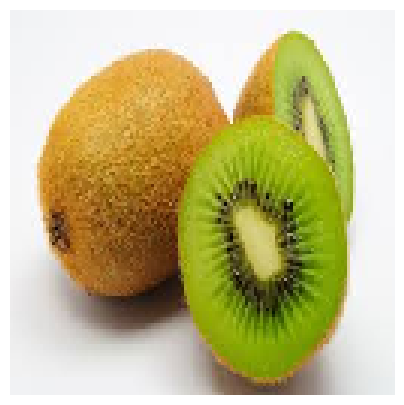

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

#Load Image
img_path = "/content/kiwi.jpg"
img = image.load_img(img_path, target_size=(128,128))
plt.figure(figsize=(5,5))
plt.axis('off')
plt.imshow(img)

#Prepare Image
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

#Predict
pred = model.predict(img_array)

class_index = np.argmax(pred)
class_name = class_names[class_index]

print("Predicted:", class_name)
print("Type:", classify_type(class_name))

**INSIGHT**
The model shows strong performance with ~96% training and validation accuracy, indicating good generalization without overfitting. The loss decreases steadily, showing stable learning. Also identified the provided image correctly.